In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
class SparseAutoencoder(nn.Module):

    def __init__(self, in_dims, h_dims, sparsity_lambda=1e-4, sparsity_target=0.05, xavier_norm_init=True):
        super().__init__()
        self.in_dims = in_dims
        self.h_dims = h_dims
        self.sparsity_lambda = sparsity_lambda
        self.sparsity_target = sparsity_target
        self.xavier_norm_init = xavier_norm_init

        self.encoder = nn.Sequential(
            nn.Linear(self.in_dims, self.h_dims),
            nn.Sigmoid()
        )
        if self.xavier_norm_init:
            nn.init.xavier_uniform_(self.encoder[0].weight)
            nn.init.constant_(self.encoder[0].bias, 0)

        self.decoder = nn.Sequential(
            nn.Linear(self.h_dims, self.in_dims),
            nn.Tanh()
        )
        if self.xavier_norm_init:
            nn.init.xavier_uniform_(self.decoder[0].weight)
            nn.init.constant_(self.decoder[0].bias, 0)

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

    def sparsity_penalty(self, encoded):
        rho_hat = torch.mean(encoded, dim=0)
        rho = self.sparsity_target
        epsilon = 1e-8
        rho_hat = torch.clamp(rho_hat, min=epsilon, max=1 - epsilon)
        kl_divergence = rho * torch.log(rho / rho_hat) + (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))
        sparsity_penalty = torch.sum(kl_divergence)
        return self.sparsity_lambda * sparsity_penalty

    def loss_function(self, x_hat, x, encoded):
        mse_loss = F.mse_loss(x_hat, x)
        sparsity_loss = self.sparsity_penalty(encoded)
        return mse_loss + sparsity_loss

In [ ]:
# ── MODIFIED FOR CIFAR-10 ──────────────────────────────────────
IN_DIMS  = 3072    # Changed from 784 (MNIST) → 3072 (32×32×3 CIFAR-10)
H_DIMS   = 1024
# ──────────────────────────────────────────────────────────────

BATCH_SIZE       = 64
N_EPOCHS         = 20
LR               = 0.0001
SPARSITY_LAMBDA  = 1e-4
SPARSITY_TARGET  = 0.05

device = torch.device('cuda' if torch.cuda.is_available() else
         'mps'  if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# ── MODIFIED FOR CIFAR-10 ──────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # 3 channels instead of 1
])

train_dataset = datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
# ──────────────────────────────────────────────────────────────

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")

Train: 50000 | Test: 10000


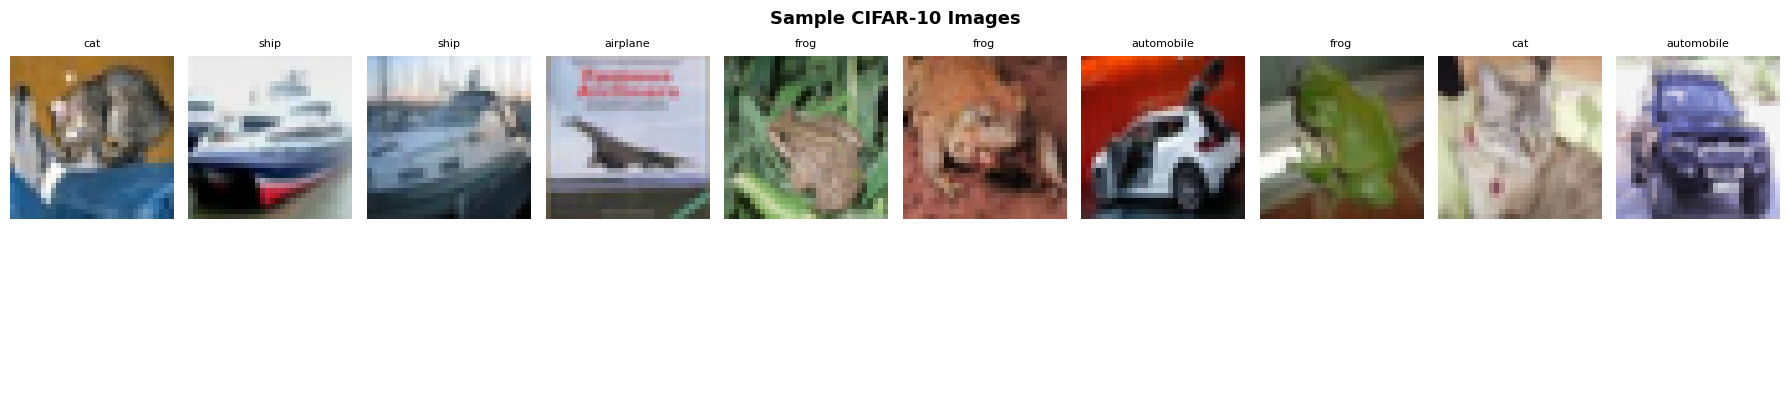

In [ ]:
def denormalize(tensor):
    return (tensor * 0.5 + 0.5).clamp(0, 1)

sample_imgs, sample_labels = next(iter(test_loader))

fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle('Sample CIFAR-10 Images', fontsize=13, fontweight='bold')
for i in range(10):
    img = denormalize(sample_imgs[i]).permute(1, 2, 0).numpy()
    axes[0, i].imshow(img)
    axes[0, i].set_title(CIFAR10_CLASSES[sample_labels[i]], fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].axis('off')   # placeholder row for reconstructions later
plt.tight_layout()
plt.show()

In [ ]:
model     = SparseAutoencoder(
    in_dims         = IN_DIMS,            # 3072 — the only change from original
    h_dims          = H_DIMS,
    sparsity_lambda = SPARSITY_LAMBDA,
    sparsity_target = SPARSITY_TARGET,
    xavier_norm_init= True
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

SparseAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=3072, out_features=1024, bias=True)
    (1): Sigmoid()
  )
  (decoder): Sequential(
    (0): Linear(in_features=1024, out_features=3072, bias=True)
    (1): Tanh()
  )
)

Total parameters: 6,295,552


In [ ]:
train_losses, train_mse_list, train_kl_list = [], [], []

for epoch in range(N_EPOCHS):
    model.train()
    total_loss = total_mse = total_kl = 0.0

    for data, _ in train_loader:
        data = data.view(data.size(0), -1).to(device)  # flatten: (B,3,32,32) → (B,3072)

        optimizer.zero_grad()
        encoded, decoded = model(data)
        loss = model.loss_function(decoded, data, encoded)
        loss.backward()

        # Gradient clipping — from original, prevents gradient explosion
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        total_mse  += F.mse_loss(decoded, data).item()
        total_kl   += model.sparsity_penalty(encoded).item()

    n = len(train_loader)
    train_losses.append(total_loss / n)
    train_mse_list.append(total_mse / n)
    train_kl_list.append(total_kl  / n)

    print(f"Epoch {epoch+1:>2}/{N_EPOCHS} | Total: {total_loss/n:.4f} | MSE: {total_mse/n:.4f} | KL: {total_kl/n:.6f}")
    print('-' * 64)

print("Training complete!")

Epoch  1/20 | Total: 0.1163 | MSE: 0.0834 | KL: 0.032906
----------------------------------------------------------------
Epoch  2/20 | Total: 0.0708 | MSE: 0.0432 | KL: 0.027660
----------------------------------------------------------------
Epoch  3/20 | Total: 0.0594 | MSE: 0.0334 | KL: 0.026006
----------------------------------------------------------------
Epoch  4/20 | Total: 0.0526 | MSE: 0.0281 | KL: 0.024565
----------------------------------------------------------------
Epoch  5/20 | Total: 0.0479 | MSE: 0.0247 | KL: 0.023177
----------------------------------------------------------------
Epoch  6/20 | Total: 0.0442 | MSE: 0.0222 | KL: 0.021938
----------------------------------------------------------------
Epoch  7/20 | Total: 0.0412 | MSE: 0.0204 | KL: 0.020794
----------------------------------------------------------------
Epoch  8/20 | Total: 0.0387 | MSE: 0.0190 | KL: 0.019753
----------------------------------------------------------------
Epoch  9/20 | Total: 0.0

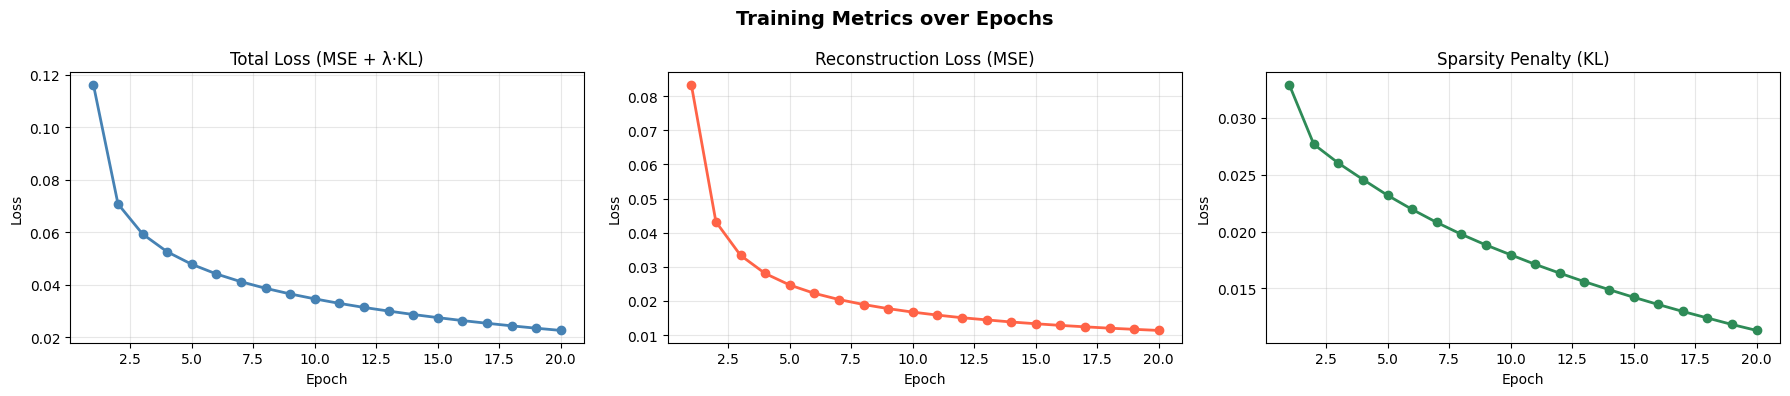

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Training Metrics over Epochs', fontsize=14, fontweight='bold')

for ax, data, title, color in zip(
    axes,
    [train_losses, train_mse_list, train_kl_list],
    ['Total Loss (MSE + λ·KL)', 'Reconstruction Loss (MSE)', 'Sparsity Penalty (KL)'],
    ['steelblue', 'tomato', 'seagreen']
):
    ax.plot(range(1, N_EPOCHS+1), data, marker='o', color=color, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
model.eval()
test_loss = test_mse = 0.0

with torch.no_grad():
    for data, _ in test_loader:
        data = data.view(data.size(0), -1).to(device)
        encoded, decoded = model(data)
        test_loss += model.loss_function(decoded, data, encoded).item()
        test_mse  += F.mse_loss(decoded, data).item()

print(f"Test Total Loss : {test_loss / len(test_loader):.4f}")
print(f"Test MSE only   : {test_mse  / len(test_loader):.4f}")

Test Total Loss : 0.0231
Test MSE only   : 0.0119


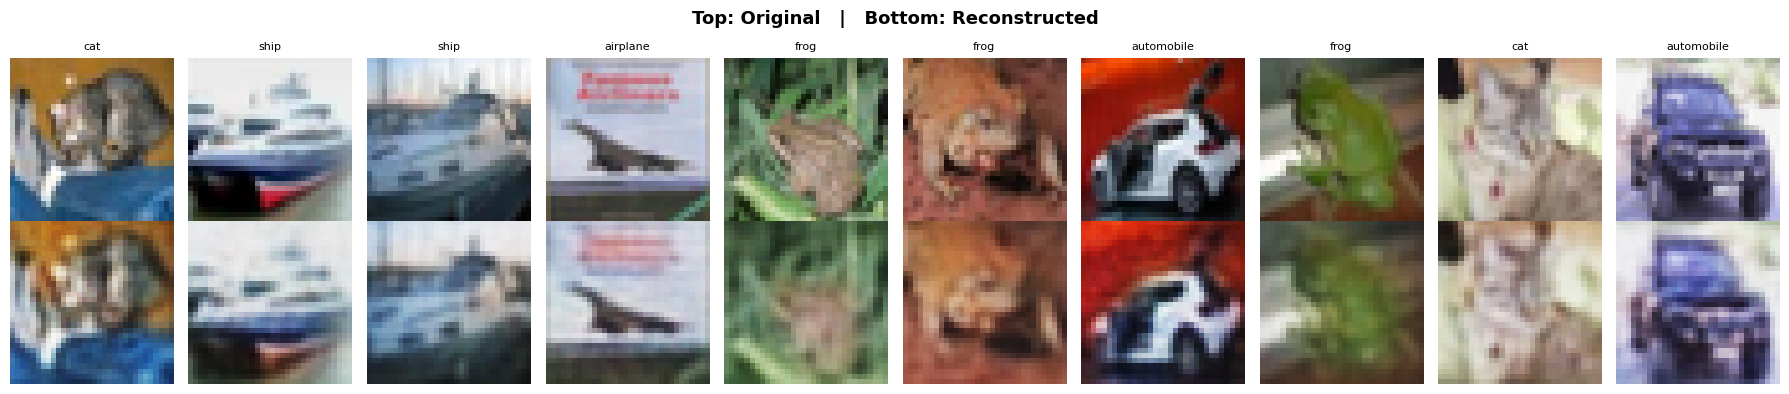

In [ ]:
model.eval()
imgs_gpu = sample_imgs[:10].to(device)

with torch.no_grad():
    encoded_viz, decoded_viz = model(imgs_gpu.view(10, -1))

recon_imgs = decoded_viz.view(-1, 3, 32, 32).cpu()

fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle('Top: Original   |   Bottom: Reconstructed', fontsize=13, fontweight='bold')

for i in range(10):
    axes[0, i].imshow(denormalize(sample_imgs[i]).permute(1,2,0).numpy())
    axes[0, i].set_title(CIFAR10_CLASSES[sample_labels[i]], fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(denormalize(recon_imgs[i]).permute(1,2,0).numpy())
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

Hidden layer has 1024 neurons


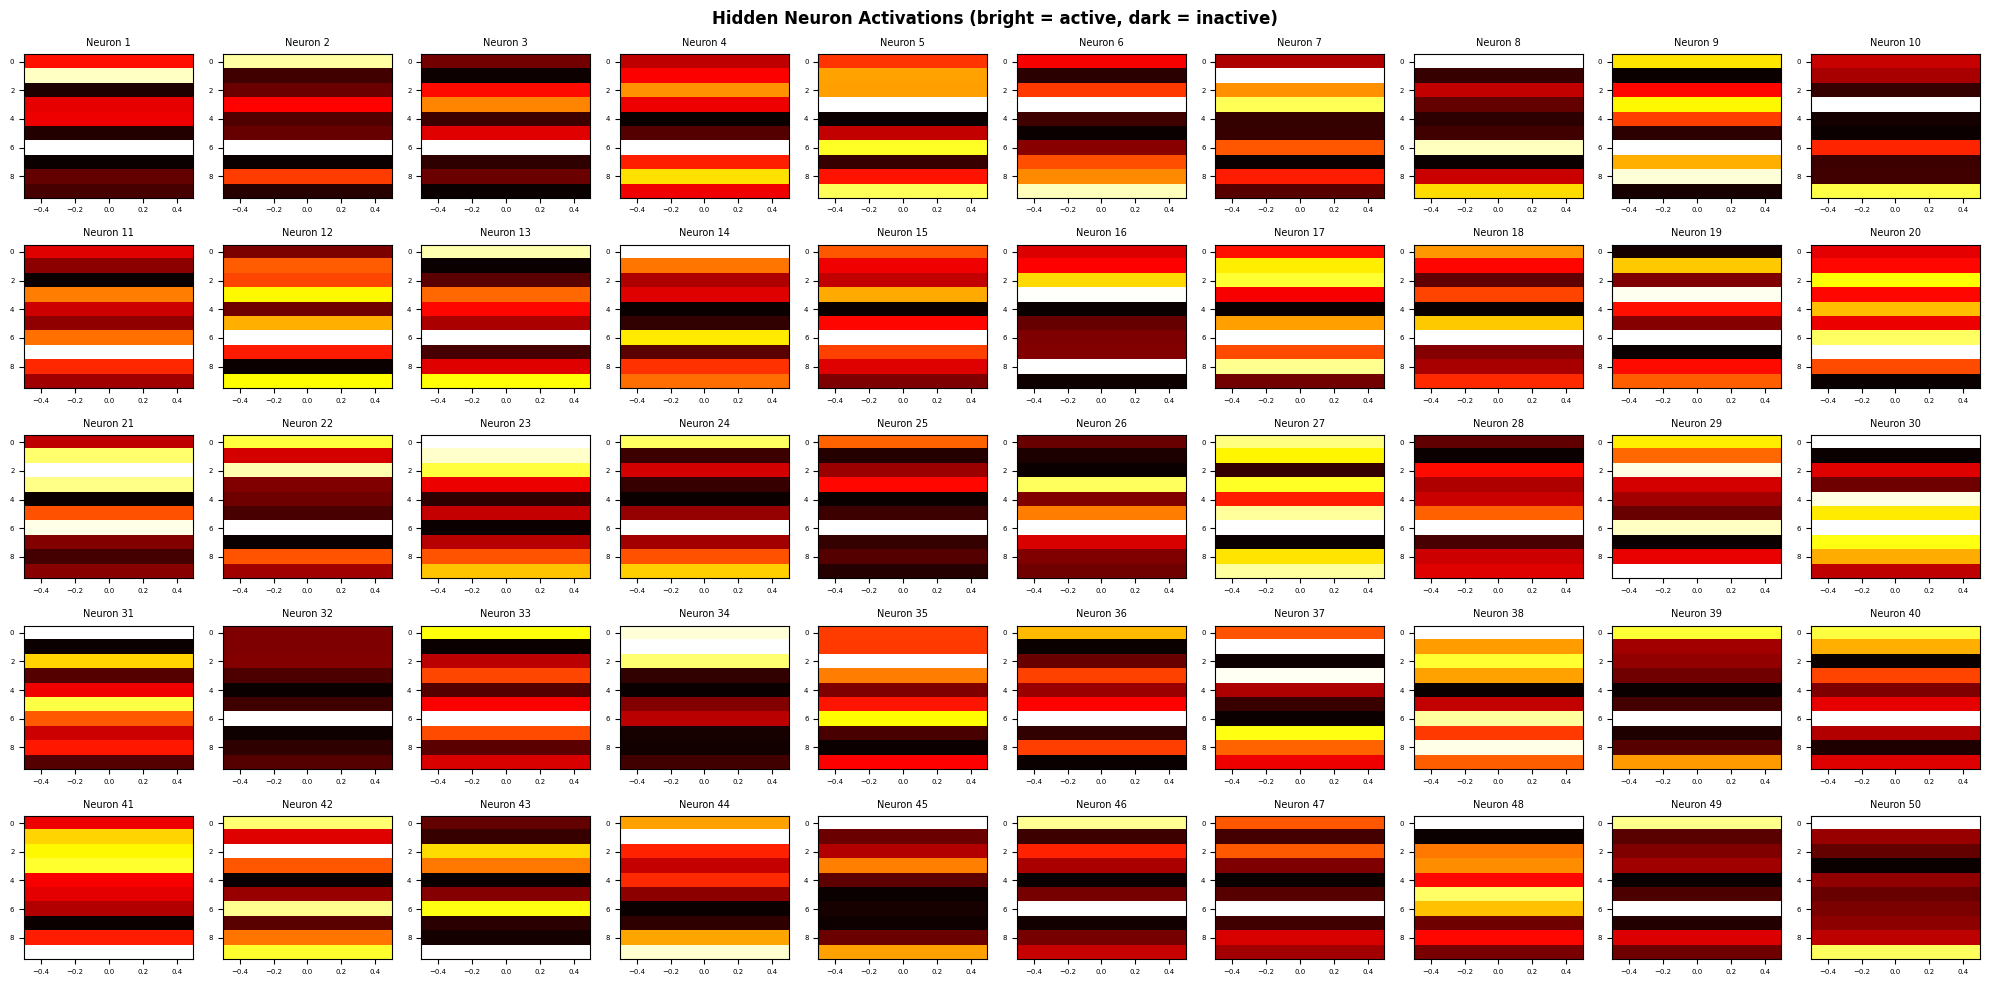

In [ ]:
def plot_activations(activations, num_neurons=50, neurons_per_row=10):
    """Reproduced exactly from original sae.py"""
    num_rows = (num_neurons + neurons_per_row - 1) // neurons_per_row
    fig, axes = plt.subplots(num_rows, neurons_per_row, figsize=(neurons_per_row * 2, num_rows * 2))
    fig.suptitle('Hidden Neuron Activations (bright = active, dark = inactive)', fontsize=12, fontweight='bold')
    axes = axes.flatten()

    for i in range(num_neurons):
        if i >= activations.shape[1]:
            break
        axes[i].imshow(activations[:, i].reshape(-1, 1), aspect='auto', cmap='hot')
        axes[i].set_title(f'Neuron {i+1}', fontsize=7)
        axes[i].tick_params(axis='both', labelsize=5)

    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Get activations from our sample batch
activations_np = encoded_viz.cpu().detach().numpy()
print(f"Hidden layer has {activations_np.shape[1]} neurons")
plot_activations(activations_np, num_neurons=50, neurons_per_row=10)

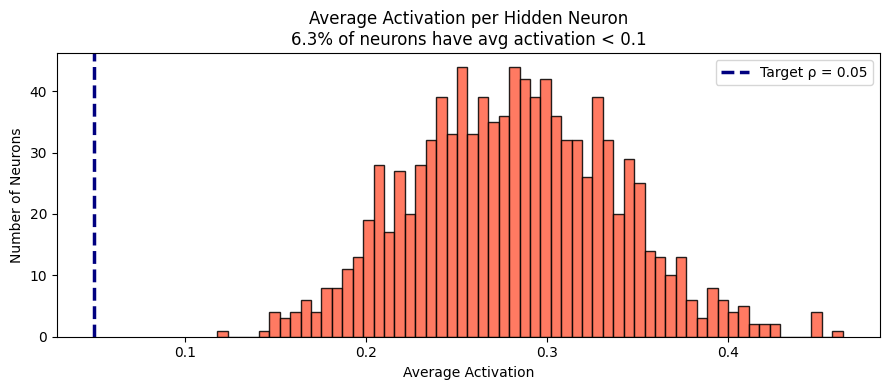

Mean activation : 0.2817  (target: 0.05)
Sparse neurons  : 6.3%


In [ ]:
avg_act      = activations_np.mean(axis=0)
sparse_pct   = (avg_act < 0.2).mean() * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(avg_act, bins=60, color='tomato', edgecolor='black', alpha=0.85)
ax.axvline(SPARSITY_TARGET, color='navy', linestyle='--', linewidth=2.5,
           label=f'Target ρ = {SPARSITY_TARGET}')
ax.set_title(f'Average Activation per Hidden Neuron\n'
             f'{sparse_pct:.1f}% of neurons have avg activation < 0.1', fontsize=12)
ax.set_xlabel('Average Activation')
ax.set_ylabel('Number of Neurons')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean activation : {avg_act.mean():.4f}  (target: {SPARSITY_TARGET})")
print(f"Sparse neurons  : {sparse_pct:.1f}%")

In [ ]:
LAMBDA_VALUES = [1e-5, 1e-4, 1e-3]
MINI_EPOCHS   = 10
lambda_results = {}

for lam in LAMBDA_VALUES:
    print(f"\nTraining with λ = {lam} ...")
    m = SparseAutoencoder(IN_DIMS, H_DIMS, sparsity_lambda=lam,
                          sparsity_target=SPARSITY_TARGET).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=LR)

    for epoch in range(MINI_EPOCHS):
        m.train()
        for data, _ in train_loader:
            data = data.view(data.size(0), -1).to(device)
            opt.zero_grad()
            enc, dec = m(data)
            loss = m.loss_function(dec, data, enc)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), max_norm=1.0)
            opt.step()
        print(f"  Epoch {epoch+1}/{MINI_EPOCHS} done")

    m.eval()
    with torch.no_grad():
        enc_b, dec_b = m(imgs_gpu.view(10, -1))

    avg = enc_b.cpu().numpy().mean(axis=0)
    mse = F.mse_loss(dec_b, imgs_gpu.view(10, -1)).item()
    lambda_results[lam] = {
        'mse': mse, 'avg_act': avg,
        'sparse_pct': (avg < 0.2).mean() * 100,
        'recon': dec_b.view(-1, 3, 32, 32).cpu()
    }
    print(f"  → MSE: {mse:.4f} | Sparse neurons: {(avg < 0.1).mean()*100:.1f}%")


Training with λ = 1e-05 ...
  Epoch 1/10 done
  Epoch 2/10 done
  Epoch 3/10 done
  Epoch 4/10 done
  Epoch 5/10 done
  Epoch 6/10 done
  Epoch 7/10 done
  Epoch 8/10 done
  Epoch 9/10 done
  Epoch 10/10 done
  → MSE: 0.0108 | Sparse neurons: 0.0%

Training with λ = 0.0001 ...
  Epoch 1/10 done
  Epoch 2/10 done
  Epoch 3/10 done
  Epoch 4/10 done
  Epoch 5/10 done
  Epoch 6/10 done
  Epoch 7/10 done
  Epoch 8/10 done
  Epoch 9/10 done
  Epoch 10/10 done
  → MSE: 0.0139 | Sparse neurons: 0.0%

Training with λ = 0.001 ...
  Epoch 1/10 done
  Epoch 2/10 done
  Epoch 3/10 done
  Epoch 4/10 done
  Epoch 5/10 done
  Epoch 6/10 done
  Epoch 7/10 done
  Epoch 8/10 done
  Epoch 9/10 done
  Epoch 10/10 done
  → MSE: 0.0377 | Sparse neurons: 0.0%


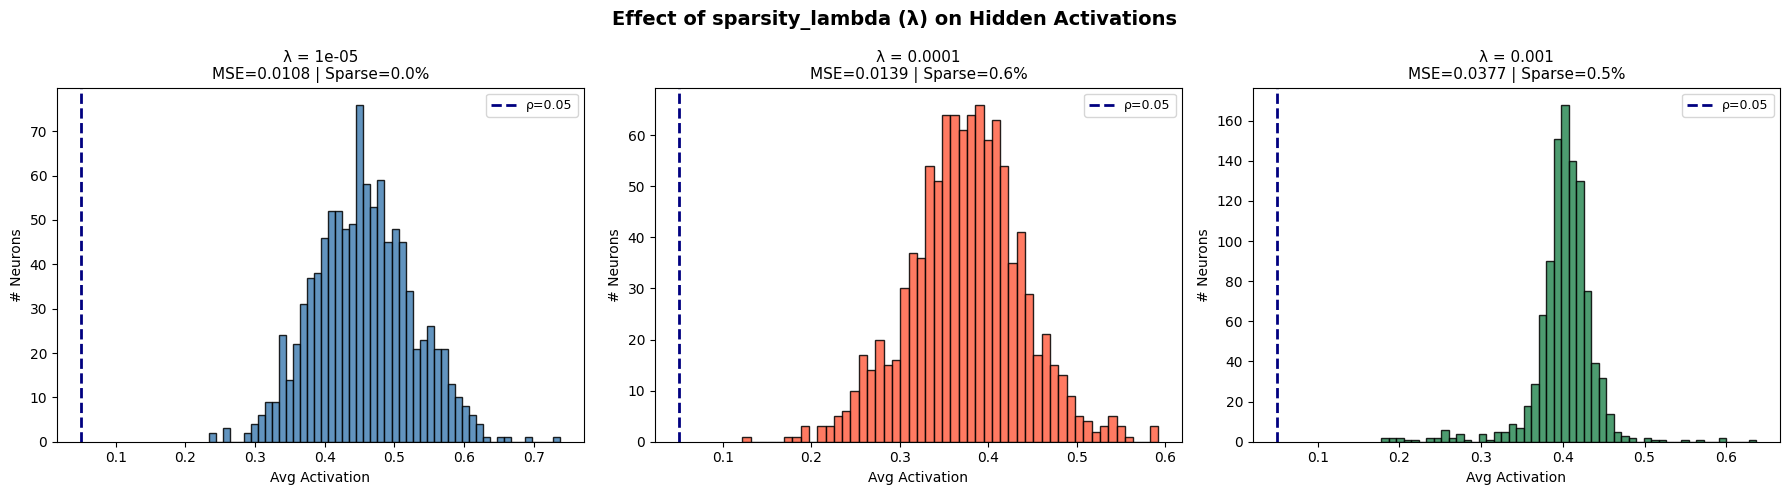

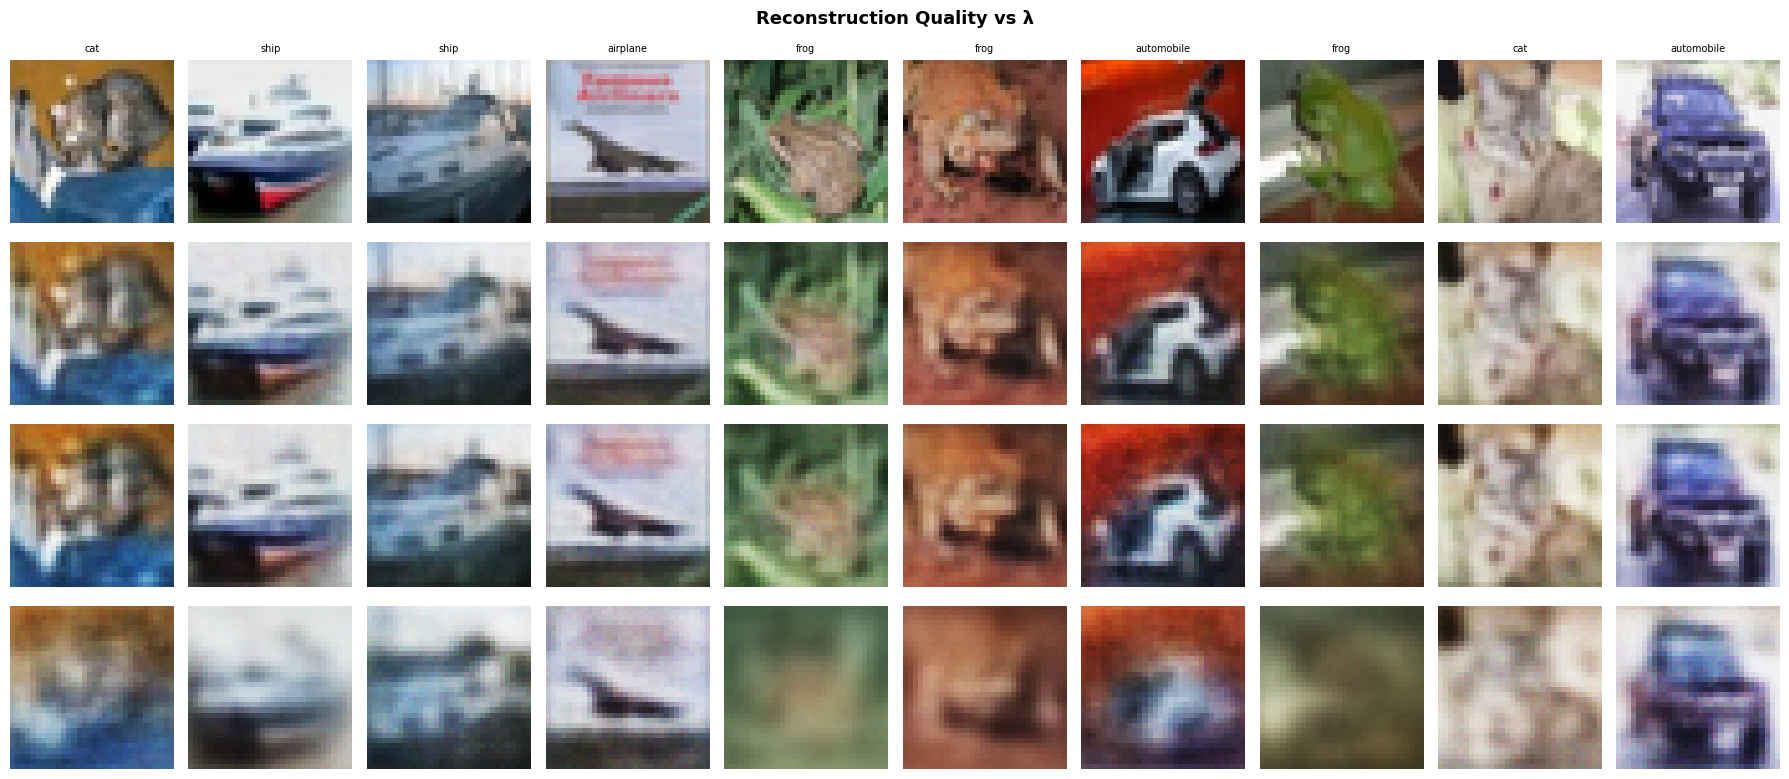

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Effect of sparsity_lambda (λ) on Hidden Activations', fontsize=14, fontweight='bold')

for ax, (lam, res), color in zip(axes, lambda_results.items(), ['steelblue','tomato','seagreen']):
    ax.hist(res['avg_act'], bins=50, color=color, edgecolor='black', alpha=0.85)
    ax.axvline(SPARSITY_TARGET, color='navy', linestyle='--', linewidth=2, label=f'ρ={SPARSITY_TARGET}')
    ax.set_title(f'λ = {lam}\nMSE={res["mse"]:.4f} | Sparse={res["sparse_pct"]:.1f}%', fontsize=11)
    ax.set_xlabel('Avg Activation')
    ax.set_ylabel('# Neurons')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Reconstruction grid
fig, axes = plt.subplots(len(LAMBDA_VALUES) + 1, 10, figsize=(18, 8))
fig.suptitle('Reconstruction Quality vs λ', fontsize=13, fontweight='bold')

for i in range(10):
    axes[0, i].imshow(denormalize(sample_imgs[i]).permute(1,2,0).numpy())
    axes[0, i].set_title(CIFAR10_CLASSES[sample_labels[i]], fontsize=7)
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=9)

for row, (lam, res) in enumerate(lambda_results.items(), start=1):
    for i in range(10):
        axes[row, i].imshow(denormalize(res['recon'][i]).permute(1,2,0).numpy())
        axes[row, i].axis('off')
    axes[row, 0].set_ylabel(f'λ={lam}', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
print("=" * 58)
print(f"{'λ':>8} | {'MSE':>8} | {'Sparse %':>10} | Interpretation")
print("=" * 58)
for lam, res in lambda_results.items():
    interp = ("Weak sparsity"   if lam < 1e-4 else
              "Balanced"        if lam == 1e-4 else
              "Strong sparsity")
    print(f"{lam:>8.0e} | {res['mse']:>8.4f} | {res['sparse_pct']:>9.1f}% | {interp}")
print("=" * 58)

       λ |      MSE |   Sparse % | Interpretation
   1e-05 |   0.0108 |       0.0% | Weak sparsity
   1e-04 |   0.0139 |       0.6% | Balanced
   1e-03 |   0.0377 |       0.5% | Strong sparsity
